<div style="border:solid Chocolate 2px; padding: 40px">

Привет, меня зовут Александр Куимов. Я буду ревьюером твоего проекта. Ты можешь обращаться ко мне на "ты"😏 Надеюсь, тебя также не смутит, если я буду обращаться к тебе на "ты", но если это неудобно, обязательно скажи об этом!

**Пожалуйста, не удаляй мои комментарии**, они будут особенно полезны для нашей работы в случае повторной проверки проекта. 

Ты также можешь реагировать на мои комментарии своими по шаблону, показанному чуть ниже. Это нужно, чтобы не создавалась путаница😉

Ты можешь найти мои комментарии, обозначенные <font color='green'>зеленым</font>, <font color='gold'>желтым</font> и <font color='red'>красным</font> цветами, например:

<br/>

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> В случае, если решение на отдельном шаге является полностью правильным.
</div>

<br/>
 
<div class="alert alert-warning">
    <h2> Комментарий ревьюера <a class="tocSkip"> </h2>
    
<b>Некоторые замечания и рекомендации💡:</b> В случае, когда решение на отдельном шаге станет еще лучше, если внести небольшие коррективы.
</div>


<br/>
<div class="alert alert-block alert-danger">
<h2> Комментарий ревьюера <a class="tocSkip"></h2>

    
<b>На доработку🤔:</b>
 В случае, когда решение на отдельном шаге требует существенной переработки и внесения правок. Напоминаю, что проект не может быть принят с первого раза, если ревью содержит комментарии, рекомендующие доработать шаги.
</div>
    
    
<br/>    
<div class="alert alert-info">
<h2> Комментарий студента: <a class="tocSkip"> </h2>

<b>👋:</b> В такой цветовой ячейке я прошу тебя оставлять свои комментарии. Если исправляешь проект на второй итерации и выше, не забывай пожалуйста указывать номер итерации, например, "Комментарий студента v.2".
</div> 

<br/>    
    
Увидев у тебя неточность, в первый раз я лишь укажу на ее наличие и дам тебе возможность самому найти и исправить ее. На реальной работе твой руководитель будет поступать также, и я пытаюсь подготовить тебя именно к работе датасаентистом. Но если ты пока не справишься с такой задачей - при следующей проверке я дам более точную подсказку!🤓

# Определение возраста покупателей

<font size="3"> 
    
**Описание задачи**: супермаркет внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- контролировать добросовестность кассиров при продаже алкоголя.
    
**Цель исследования**: разработка модели, которая по фотографии определит приблизительный возраст человека.
    
**Описание данных**: заказчик предоставил набор фотографий людей с указанием возраста.   
    
**План выполнения**:

- загрузить данные;
- провести исследовательский анализ имеющихся данных;
- подготовить данные к обучению;
- обучить нейронную сеть регрессии. 
    
Качество работы модели будет оцениваться по метрике `MAE`, значение метрики на тестовой выборке не должно привышать 8.

## Загрузка данных и библиотек

###  Импорт библиотек

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno matplotlib==3.8.3 scikit-learn==1.5.2 numpy==1.23.5 numba==0.60.0 -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from warnings import simplefilter
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# seed для генераторов случайных чисел
SEED = 42

# настройки графиков
PLOT_DPI = 150
sns.set_theme(style="darkgrid", palette="crest")
rcParams['figure.figsize'] = 12, 6
plt.rc(
       'axes',
       labelweight='bold',
       titlesize=16,
       titlepad=10,
      )

# остальные настройки
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

# путь к директориям
PATH_REMOTE = '/datasets/faces/labels.csv'
PATH_LOCAL = '/Users/kasper/Documents/TS/labels.csv'

### Чтение данных

<font size="3"> Считаем имеющиеся данные и сохраним в переменную `labels`:

In [4]:
if os.path.exists(PATH_LOCAL):
    labels = pd.read_csv(PATH_LOCAL)
    display(labels.head())
elif os.path.exists(PATH_REMOTE):
    labels = pd.read_csv(PATH_REMOTE)
    display(labels.head())
else:
    print('Something is wrong')

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


In [5]:
# генератор для загрузки изображений из полученного датафрейма
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory='/datasets/faces/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        seed=12345) 

Found 7591 validated image filenames.


### Изучение данных

<font size="3"> Изучим структуру и полноту полученных данных.

In [6]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


<Axes: >

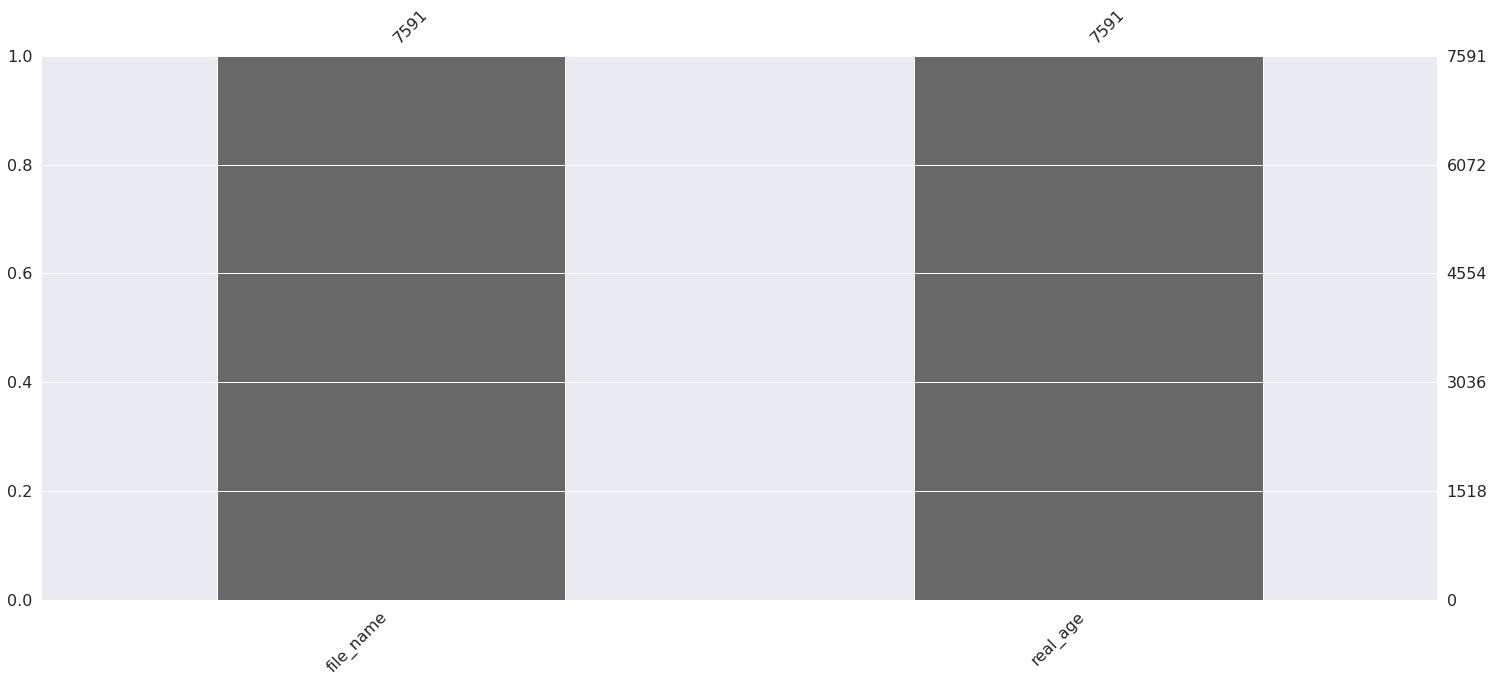

In [7]:
msno.bar(labels)

<font size="3">
    
**Вывод**
    
Полученный датафрейм содержит следующие данные:

* `file_name` — название изображения;
* `real_age` — целевой признак, возраст человека на снимке.
    
В датасете содержится 7591 записей, что является небольшой выборкой для оценки возраста. Пропущенные значения отсутствуют.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> 
    
Размер выборки выведен. Выборка относительно небольшая, но мы еще можем нарастить ее, применяя аугментации


<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

## Анализ и обработка данных

<font size="3"> Изучим подробнее полученные данные.

<font size="3"> 
    
**Дубликаты**

Проверим данные на наличие дубликатов.

In [8]:
print(f'Количество дубликатов в данных:{labels.duplicated().sum()}')

Количество дубликатов в данных:0


<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3"> 
    
**Визуализация целевого признака**
    
Изучим распределение таргета.

,count,mean,std,min,25%,50%,75%,max
real_age,7591.0,31.201159,17.14506,1.0,20.0,29.0,41.0,100.0


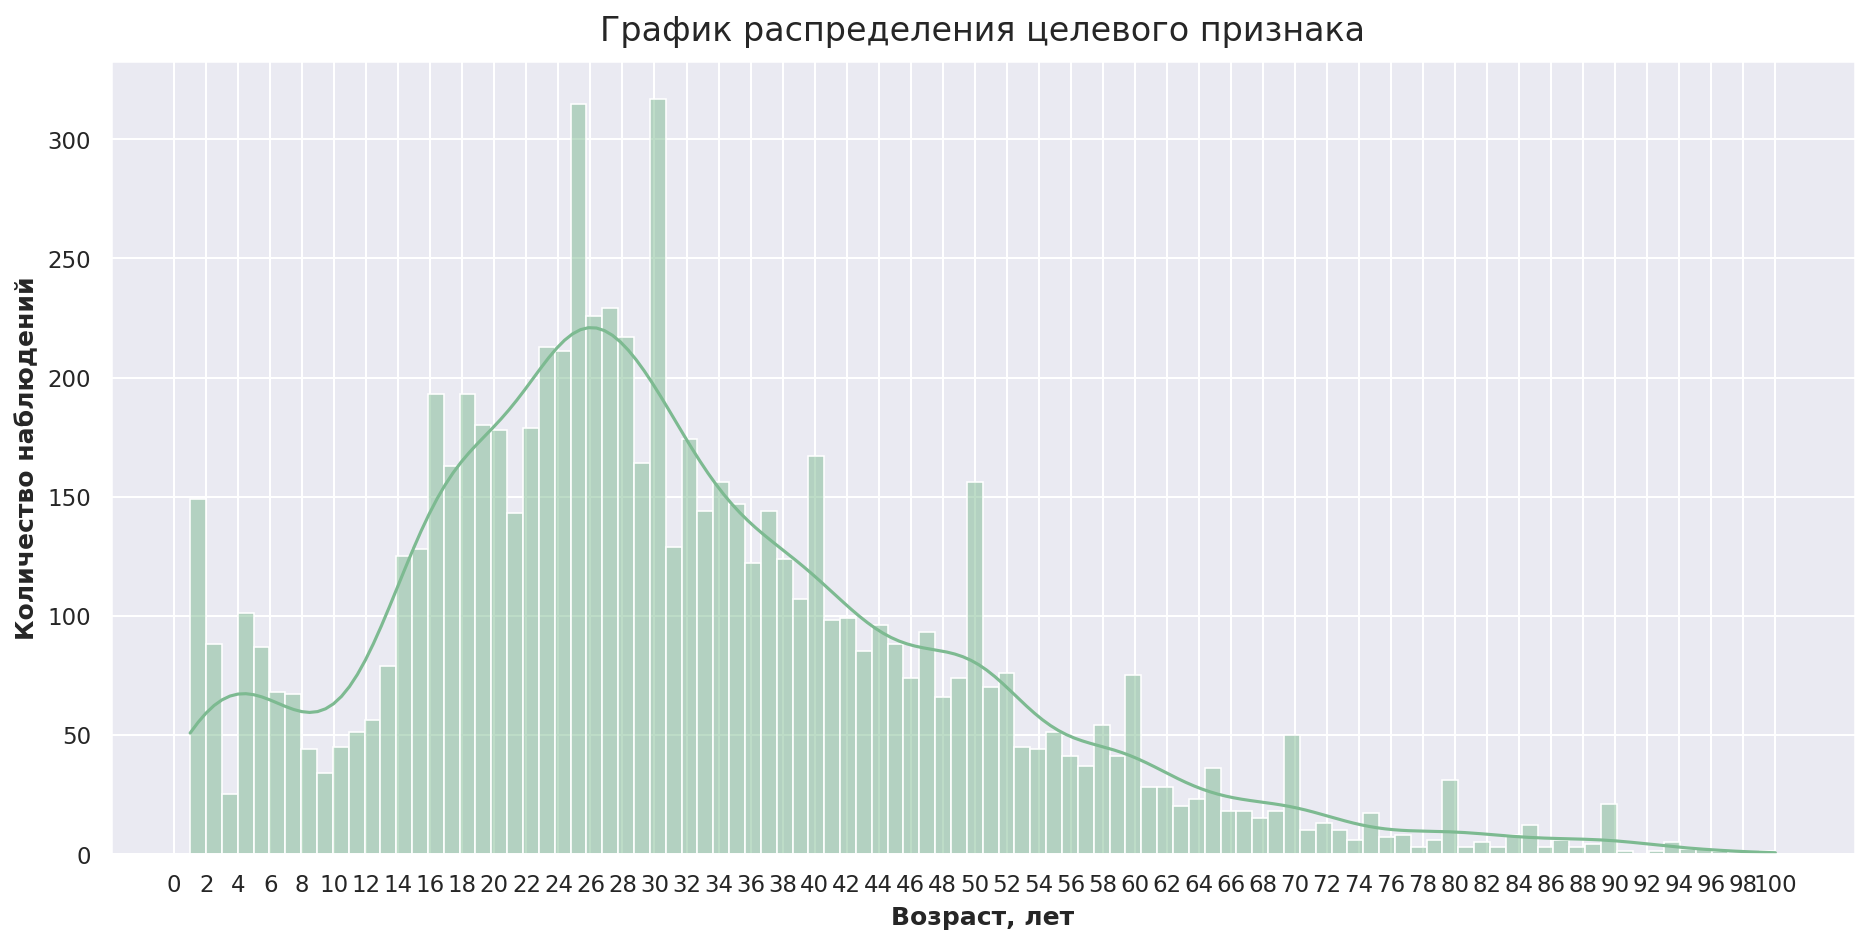

In [9]:
display(labels.describe().T)

fig, ax = plt.subplots(figsize=(15,7), dpi=PLOT_DPI)
sns.histplot(x=labels.real_age, bins=100, kde=True)
ax.set_xticks(range(0, labels.real_age.max()+1, 2))

plt.title('График распределения целевого признака')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество наблюдений');

<font size="3"> 

**Вывод:**
    
Распределение признака ассиметрично с длинным правым хвостом, что может снизить точность прогноза в этой области. 

Межквартильный размах в данных располагается в промежутке 20 - 41 год со средним значением в 31 год.
    
На круглых датах (юбилейный возраст) наблюдаются пики, возможно для части наблюдений указан приблизительный возраст человека.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> 
    
Гистограмма целевого признака выведена верно. Пики в районе "юбилейных" лет, они тут могут быть связаны с тем, что настоящий возраст был неизвестен тому, кто размечал датасет, и он попросту округлял его. Отлично, что была проведена работа над оформлением графика)

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3"> 
    
**Изучение изображений**
    
Рассмотрим подробнее имеющиеся изображения.

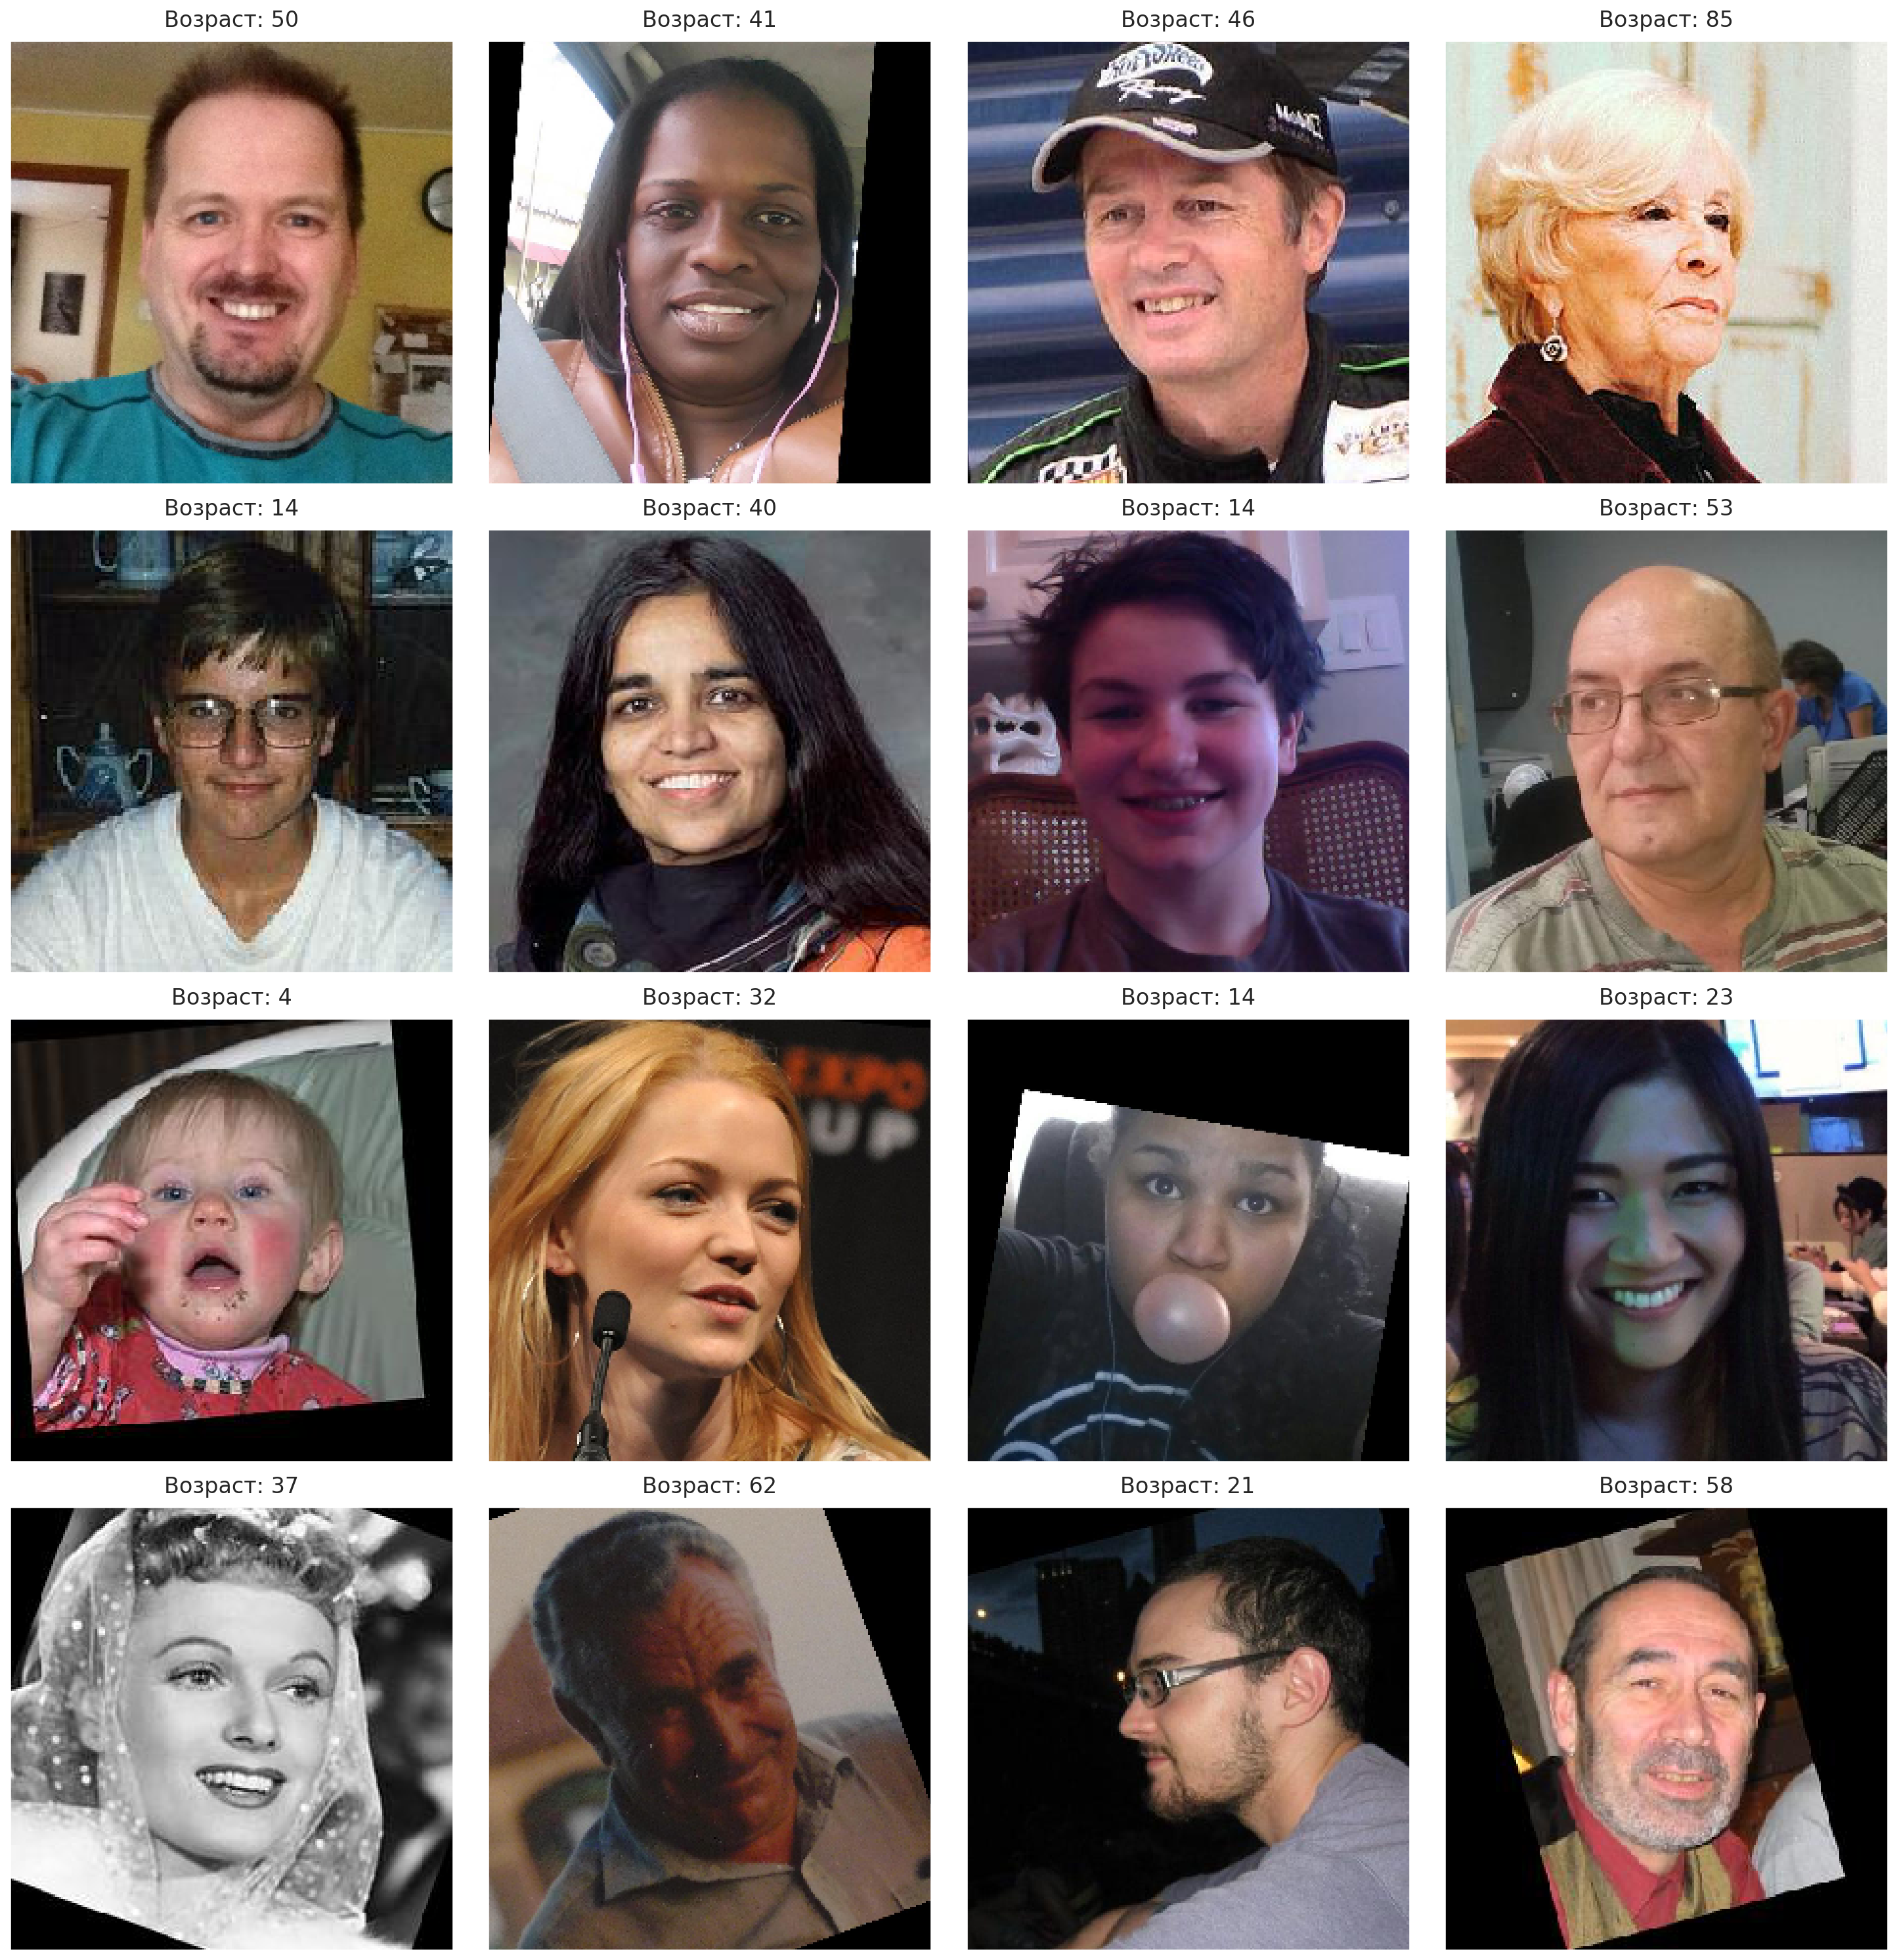

In [10]:
# выведем 16 фотографий
features, target = next(train_gen_flow)
fig = plt.figure(figsize=(20,20), dpi=PLOT_DPI)
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(features[i])
    plt.title('Возраст: {}'.format(target[i]))
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

<font size="3"> 

**Вывод:**

Выявлены следующие особенности:   

- на фотографиях присутствуют люди разных национальностей;
- в выборке присутствуют цветные и ч/б снимки;
- в кадре имеются объекты, частично скрвающие лицо (борода, очки, головной убор);
- часть изображений подверглась вращению и заполнена цветом в пустых пространствах;
- на некоторых снимках люди не смотрят в камеру или изображены в профиль;
- также есть снимки плохого качества с высоким размытием.

Данные особенности могут отрицательно сказаться на качестве модели.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b>
     
Примеры фотографий выведены. Отлично, что указан возраст у фотографий!

---

<font size="3"> 

**Вывод раздела:**

- в данных нет пропущенных значений и дубликатов;
- все снимки размечены в допустимом диапазоне человеческого возраста (1 - 100 лет);
- выборка содержит небольшое количество объектов: всего 7591 фотографий, потребуется аугментация данных или применение предобученных моделей;
- возрастные группы представлены в данных неравномерно, а также для части объектов может быть указан приблизительный возраст;
- в выборке присутствуют разноплановые снимки: разное качество фото, ракурс, ближний и дальний план, наличие или отсутствие посторонних предметов в кадре - всё это может негативно сказаться на качестве модели.

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично !👍:</b>
    
Анализ проведен корректно.
        
Добавлю, общая ориентация фотографий примерно одинакова - в некоторых фото их уже повернули за нас, чтобы выровнять положение лица, значит нам их не обязательно поворачивать, а начальный размер изображений отличается, в силу того, что визуально заметно различное качество фото, где-то есть черные рамки (они не несут полезной информации). В итоге, размер изображений мы приведем к единому перед обучением модели.
    
Советую изучить базовые возможности аугментаций в <a href="https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator">документации</a> или в <a href="https://towardsdatascience.com/machinex-image-data-augmentation-using-keras-b459ef87cd22">статье</a>.     
 </div>

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

##  Обучение модели

<font size="3"> 
    
**Код модели**

Применим модель на базе `ResNet50` + полносвязный слой с `Relu` активацией и обучим модель на 10 эпохах.
    
Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке.

```python

# импорт библиотек
import tensorflow as tf
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import pandas as pd

# загрузка данных для обучения
def load_train(path):

    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25,
                                 horizontal_flip=True,
                                 width_shift_range=0.1,
                                 height_shift_range=0.1,
                                 rescale=1./255)

    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='training',
        seed=42)

    return train_gen_flow

# загрузка данных для тестирования
def load_test(path):

    labels = pd.read_csv(path + 'labels.csv')
    datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)

    train_gen_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=16,
        class_mode='raw',
        subset='validation',
        seed=42)

    return train_gen_flow

# архитектура нейронной сети
def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                        weights='imagenet',
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    optimizer = Adam(lr=0.0001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# обучение модели
def train_model(model, train_data, test_data, batch_size=None, epochs=10,
                steps_per_epoch=None, validation_steps=None):



    if steps_per_epoch==None: steps_per_epoch = len(train_data)
    if validation_steps==None: validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size,
              epochs=epochs,
              steps_per_epoch = steps_per_epoch,
              validation_steps = validation_steps,
              verbose=2,
              shuffle=True)

    return model
```

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> 
    
Модель определена правильно! Отлично, что применен горизонтальный флип на тренировочной части

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

<font size="3"> 
    
**Результат вывода модели**

```
Found 5694 validated image filenames.
Found 1897 validated image filenames.

<class 'tensorflow.python.keras.engine.sequential.Sequential'>

Train for 356 steps, validate for 119 steps
Epoch 1/10
356/356 - 121s - loss: 218.2374 - mae: 10.6885 - val_loss: 700.4510 - val_mae: 21.4616
Epoch 2/10
356/356 - 111s - loss: 99.8374 - mae: 7.5585 - val_loss: 152.6360 - val_mae: 9.4293
Epoch 3/10
356/356 - 108s - loss: 75.4393 - mae: 6.6093 - val_loss: 126.8653 - val_mae: 8.6270
Epoch 4/10
356/356 - 101s - loss: 59.3821 - mae: 5.9054 - val_loss: 92.4363 - val_mae: 7.2059
Epoch 5/10
356/356 - 108s - loss: 52.7928 - mae: 5.5523 - val_loss: 86.1519 - val_mae: 6.9692
Epoch 6/10
356/356 - 109s - loss: 44.7277 - mae: 5.1307 - val_loss: 78.4705 - val_mae: 6.6568
Epoch 7/10
356/356 - 112s - loss: 36.9221 - mae: 4.6997 - val_loss: 83.4686 - val_mae: 6.8805
Epoch 8/10
356/356 - 118s - loss: 29.2823 - mae: 4.1843 - val_loss: 72.1429 - val_mae: 6.2945
Epoch 9/10
356/356 - 119s - loss: 26.0869 - mae: 3.9231 - val_loss: 73.0294 - val_mae: 6.2443
Epoch 10/10
356/356 - 117s - loss: 24.9242 - mae: 3.8447 - val_loss: 77.3941 - val_mae: 6.3554

119/119 - 13s - loss: 77.3941 - mae: 6.3554
Test MAE: 6.3554

```

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> 
    
Отличный результат по метрике)

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

##  Анализ обученной модели

<font size="3"> Cоберём полученные метрики обучения из вывода модели в таблицу.

In [11]:
model_result = pd.DataFrame({
    'epochs': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'train_loss': [218.2374, 99.8374, 75.4393, 59.3821, 52.7928, 44.7277, 36.9221, 29.2823, 26.0869, 24.9242],
    'train_mae': [10.6885, 7.5585, 6.6093, 5.9054, 5.5523, 5.1307, 4.6997, 4.1843, 3.9231, 3.8447],
    'val_loss': [700.4510, 152.6360, 126.8653, 92.4363, 86.1519, 78.4705, 83.4686, 72.1429, 73.0294, 77.3941],
    'val_mae': [21.4616, 9.4293, 8.6270, 7.2059, 6.9692, 6.6568, 6.8805, 6.2945, 6.2443, 6.3554]
})

display(model_result)

,epochs,train_loss,train_mae,val_loss,val_mae
0,1,218.2374,10.6885,700.4510,21.4616
1,2,99.8374,7.5585,152.6360,9.4293
2,3,75.4393,6.6093,126.8653,8.6270
3,4,59.3821,5.9054,92.4363,7.2059
4,5,52.7928,5.5523,86.1519,6.9692
5,6,44.7277,5.1307,78.4705,6.6568
6,7,36.9221,4.6997,83.4686,6.8805
7,8,29.2823,4.1843,72.1429,6.2945
8,9,26.0869,3.9231,73.0294,6.2443
9,10,24.9242,3.8447,77.3941,6.3554


<font size="3"> Визуализируем результат обучения модели.

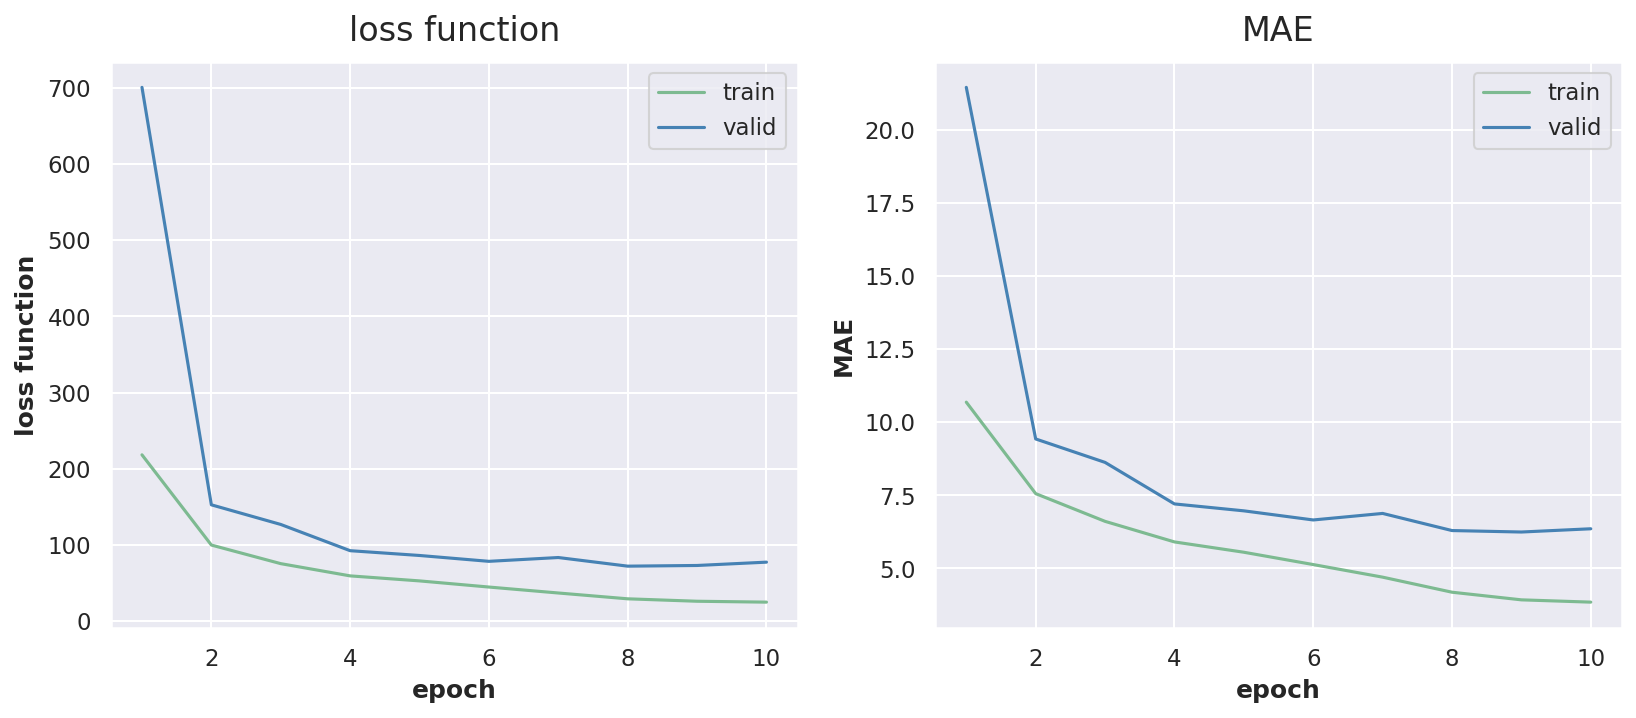

In [12]:
fig, ax = plt.subplots(figsize=(13,5), ncols=2, dpi=PLOT_DPI)

sns.lineplot(x=model_result.epochs, y=model_result.train_loss, ax=ax[0], label='train')
sns.lineplot(x=model_result.epochs, y=model_result.val_loss, ax=ax[0], label='valid', color='steelblue')

sns.lineplot(x=model_result.epochs, y=model_result.train_mae, ax=ax[1], label='train')
sns.lineplot(x=model_result.epochs, y=model_result.val_mae, ax=ax[1], label='valid', color='steelblue')

ax[0].set_title('loss function')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss function')
ax[1].set_title('MAE')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('MAE')

plt.show()

<font size="3"> 

**Вывод:**
    
Обученная модель построена на базе архитектуры `ResNet50` с заменой финального слоя для задачи регрессии.

Функция потерь на валидационной выборке уменьшается - это говорит о том, что модель обучается и улучшает свои предсказания. При этом с 5-й эпохи метрика валидационного набора данных перестает значимо улучшаться, а значит дальнейшее увеличение числа эпох может не привести к улучшению результатов.
    
Модель демонстрирует хорошую точность: метрика **MAE** составила **6.3554**. Это говорит о том, что модель ошибается на ~ 6 лет. 
    
Качество модели соответствует минимальным требованиям Заказчика, но дополнительно стоит отметить, что данная погрешность может осложнить контроль продажи алкоголя, ведь ошибка в 6 лет при определении возраста подростка является существенной.
    
Для решения данной бизнес-задачи стоит попробовать обучить модель специально для задачи определения совершеннолетия покупателя. Для этого необходимо увеличить количество наблюдений пограничного возраста продажи алкоголя в тренировочной выборке, очистить набор данных от размытых и форматированных изображений низкого качества. Возможно с такой задачей лучше сравится модель классификации, написанная для целей определения возрастной группы покупателя.

<div class="alert alert-success"> 
<h2> Комментарий ревьюера  <a class="tocSkip"> </h2>

<b>Все отлично!👍:</b> Выводы вполне логичные)

<hr style="width: 100%; height: 1px; background-color: #99b9b6;">

##  Общий вывод

<font size="3"> 
    
Целью данного исследования являлась разработка модели, которая по фотографии определит приблизительный возраст человека.
    
> **Исследовательский анализ**
- изучены пропуски и дубликаты в данных;    
- исследовано распределение целевого признака, выявлен ряд недостатков входных данных:
  - сильная ассиметрия распределения;
  - не все возрастные группы представлены одинаково полно;
  - возраст многих объектов скорее всего указан приблизительно.
- изучены имеющиеся изображения, выявлены потенциальные сложности: 
  - в кадре имеются объекты, частично скрвающие лицо (борода, очки, головной убор);
  - часть изображений подверглась вращению и заполнена цветом в пустых пространствах;
  - на некоторых снимках люди не смотрят в камеру или изображены в профиль;
  - есть снимки плохого качества с высоким размытием.

    
> **Обучение модели**

Построена и обучена модель на базе архитектуры `ResNet50` с заменой финального слоя для задачи регрессии.
    
Характеристики модели и заданные параметры:

1. **Модель**: `ResNet50`, предобученная на `ImageNet`;
2. **Аугментация**: горизонтальный сдвиг, сдвиг по ширине и высоте на тренировочных данных;
3. **Размер батча**: 16 изображений;
4. **Learning rate**: оптимизатор Adam с learning rate 0.0001;
5. **Количество эпох**: 10.
    
При обучении на 10 эпохах удалось достичь качества модели по метрике `MAE` - **6.3554**, что соответствует требованиям Заказчика.

<div style="border:solid Chocolate 2px; padding: 40px">


<h2> Итоговый комментарий ревьюера (общий вывод по проекту) <a class="tocSkip"> </h2>    
    
  
У меня сложилось хорошее общее впечатление о проекте, тебе удалось неплохо справиться с проектом. Молодец! Загружены данные для анализа, изучен каждый параметр, модель построена и протестирована. Тебе удалось успешно справиться с первой задачей в области компьютерного зрения. Поздравляю!
    
Отмечу отдельные положительные моменты проекта🙂:
    
- радует, что проект хорошо структурирован, приятно проверять такие работы;
- есть красивые визуализации в проекте.
    
Проект может быть зачтен, но я его отправлю назад, чтобы у тебя была возможность задать вопросы и внести правки, при желании. Однако, ты можешь просто вернуть проект в таком же виде и я его зачту.
     
</div>

<br/>    
<div class="alert alert-info">
<h2> Комментарий студента: <a class="tocSkip"> </h2>

<b>👋:</b> Александр, привет! Спасибо за ревью 🤝🏼
<br>Дополнительных вопросов пока нет)
</div> 

<div style="border:solid Chocolate 2px; padding: 40px">


<h2>  Итоговый комментарий ревьюера 2 (итоговый вывод по проекту) <a class="tocSkip"> </h2>    
    
      
  
Теперь почти идеально, молодец! Принимаю твой проект)
    
Могу поделиться такими ссылками для углубленного изучения темы спринта:
    
- Видеокурс от Stanford University: https://www.youtube.com/watch?v=vT1JzLTH4G4&list=PLC1qU-LWwrF64f4QKQT-Vg5Wr4qEE1Zxk
    
- Курс от Физтех-школы Прикладной Математики и Информатики МФТИ: https://vk.com/dlschool_mipt
    
- Курс Нейронные сети и компьютерное зрение от Sumsung: https://stepik.org/course/50352/promo#toc    
    
    
В этом проекте все шаги отработаны. С интересом читал твои размышления, код и выводы. Что ещё для дальнейшего улучшения качества возможно сделать?
    
Опишу здесь некоторые идеи:
    
1. Качество данных на входе: оценить еще раз возраст по фото.
2. Анализ ошибок: к примеру модель сильно ошибается на сегменте пожилых людей, зато почти идеально работает с детьми. Тогда мы поймем, каких возрастов фото было бы хорошо добавить в выборку для дообучения.
3. Дополнительно изучить распределение целевого признака, возможно что выборка была составлена неслучайным образом (видна небольшая бимодальность), посмотреть, каких возрастных групп представлено мало, чтобы их потом добавить в выборку.
    
Но цель нашего проекта достигнута. Рад был тебе помочь)
    
Удачи тебе в финальном проекте!
  
</div>